In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [3]:
DATASET_DIR = r"D:\Advanced data science Lab\Assignment_3\archive (5)"

print("Dataset Path:")
print(DATASET_DIR)

Dataset Path:
D:\Advanced data science Lab\Assignment_3\archive (5)


In [4]:
if os.path.exists(DATASET_DIR):
    print("✅ Dataset path found!")
else:
    print("❌ Dataset path not found!")

✅ Dataset path found!


In [5]:
print("Folders inside dataset:\n")

for folder in os.listdir(DATASET_DIR):
    
    folder_path = os.path.join(DATASET_DIR, folder)
    
    if os.path.isdir(folder_path):
        print(folder)

Folders inside dataset:

fresh_peaches_done
fresh_pomegranates_done
fresh_strawberries_done
rotten_peaches_done
rotten_pomegranates_done
rotten_strawberries_done


In [6]:
print("Image count for each class:\n")

total_images = 0

for folder in sorted(os.listdir(DATASET_DIR)):
    
    folder_path = os.path.join(DATASET_DIR, folder)
    
    if os.path.isdir(folder_path):
        
        image_count = 0
        
        for file in os.listdir(folder_path):
            
            if file.lower().endswith(
                ('.jpg', '.jpeg', '.png')
            ):
                image_count += 1
        
        print(f"{folder}: {image_count} images")
        
        total_images += image_count

print("\nTotal Images:", total_images)


Image count for each class:

fresh_peaches_done: 250 images
fresh_pomegranates_done: 311 images
fresh_strawberries_done: 250 images
rotten_peaches_done: 343 images
rotten_pomegranates_done: 250 images
rotten_strawberries_done: 251 images

Total Images: 1655


In [7]:
datagen = ImageDataGenerator(
    
    rescale=1./255,
    
    rotation_range=20,
    
    zoom_range=0.2,
    
    horizontal_flip=True,
    
    validation_split=0.2
)

print("✅ Data generator created!")

✅ Data generator created!


In [8]:
train_generator = datagen.flow_from_directory(
    
    DATASET_DIR,
    
    target_size=(64, 64),
    
    batch_size=32,
    
    class_mode='categorical',
    
    subset='training',
    
    shuffle=True
)

Found 1325 images belonging to 6 classes.


In [9]:
validation_generator = datagen.flow_from_directory(
    
    DATASET_DIR,
    
    target_size=(64, 64),
    
    batch_size=32,
    
    class_mode='categorical',
    
    subset='validation',
    
    shuffle=False
)

Found 330 images belonging to 6 classes.


In [10]:
class_indices = train_generator.class_indices

print("Class Indices:\n")

for class_name, index in class_indices.items():
    print(index, ":", class_name)

Class Indices:

0 : fresh_peaches_done
1 : fresh_pomegranates_done
2 : fresh_strawberries_done
3 : rotten_peaches_done
4 : rotten_pomegranates_done
5 : rotten_strawberries_done


In [11]:
class_names = list(
    train_generator.class_indices.keys()
)

print("Class Names:")
print(class_names)

Class Names:
['fresh_peaches_done', 'fresh_pomegranates_done', 'fresh_strawberries_done', 'rotten_peaches_done', 'rotten_pomegranates_done', 'rotten_strawberries_done']


In [12]:
images, labels = next(train_generator)

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: (32, 64, 64, 3)
Label batch shape: (32, 6)


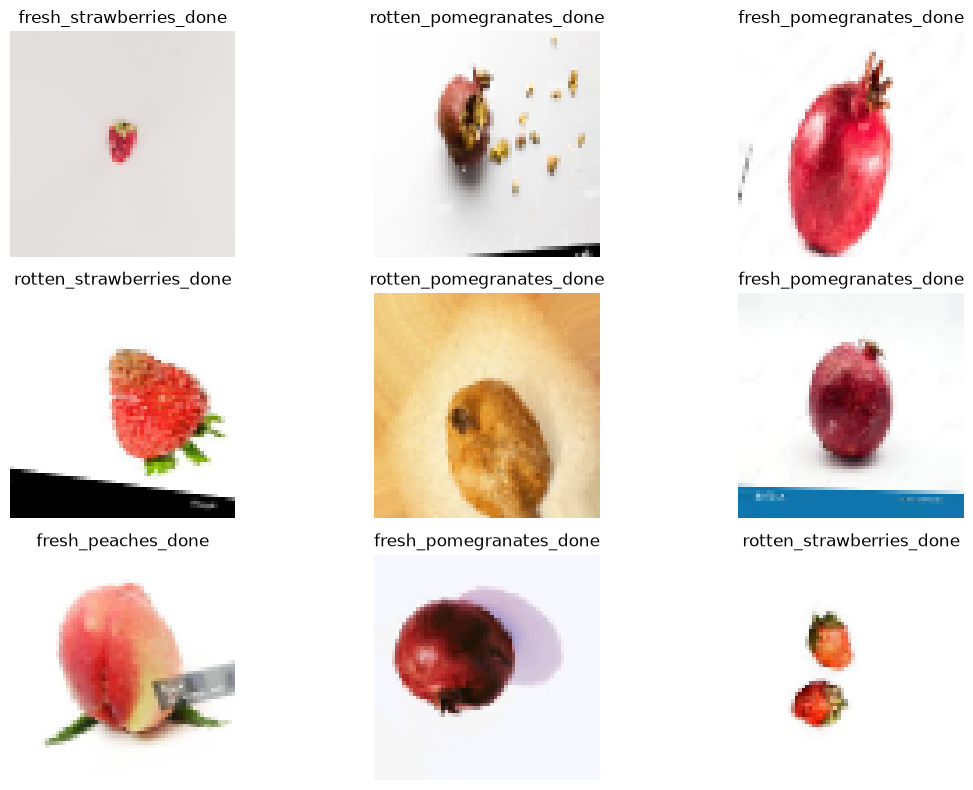

In [13]:
plt.figure(figsize=(12, 8))

for i in range(9):
    
    plt.subplot(3, 3, i + 1)
    
    plt.imshow(images[i])
    
    class_index = np.argmax(labels[i])
    
    plt.title(class_names[class_index])
    
    plt.axis('off')

plt.tight_layout()
plt.show()

In [14]:
print("Minimum pixel value:", images.min())
print("Maximum pixel value:", images.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [15]:
model = Sequential([

    # Convolution Layer 1
    Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(64, 64, 3)
    ),

    # Pooling Layer 1
    MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Convolution Layer 2
    Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),

    # Pooling Layer 2
    MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Flatten
    Flatten(),

    # Fully Connected Layer
    Dense(
        128,
        activation='relu'
    ),

    # Dropout
    Dropout(0.3),

    # Output Layer
    Dense(
        6,
        activation='softmax'
    )
])

d:\Advanced data science Lab\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,926 (6.20 MB)

 Trainable params: 1,625,926 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
    
    optimizer='adam',
    
    loss='categorical_crossentropy',
    
    metrics=['accuracy']
)

print("✅ Model compiled successfully!")

✅ Model compiled successfully!


In [18]:
history = model.fit(
    
    train_generator,
    
    epochs=10,
    
    validation_data=validation_generator
)

Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 30s 593ms/step - accuracy: 0.2898 - loss: 1.7353 - val_accuracy: 0.4788 - val_loss: 1.4230
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - accuracy: 0.4996 - loss: 1.3123 - val_accuracy: 0.5273 - val_loss: 1.2474
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.5419 - loss: 1.1897 - val_accuracy: 0.5485 - val_loss: 1.1553
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.5947 - loss: 1.0369 - val_accuracy: 0.6152 - val_loss: 1.0884
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.6611 - loss: 0.9489 - val_accuracy: 0.6061 - val_loss: 1.0799
Epoch 6/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 9s 214ms/step - accuracy: 0.6430 - loss: 0.9484 - val_accuracy: 0.6455 - val_loss: 1.0075
Epoch 7/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 249ms/step - accuracy: 0.6974 - loss: 0.8216 - val_accuracy: 0.5909 - val_loss: 1.1006
Epoch 8/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 9s 217ms/step - accuracy: 0.7155 - loss: 0.7894 - val_accuracy: 0.66

In [19]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


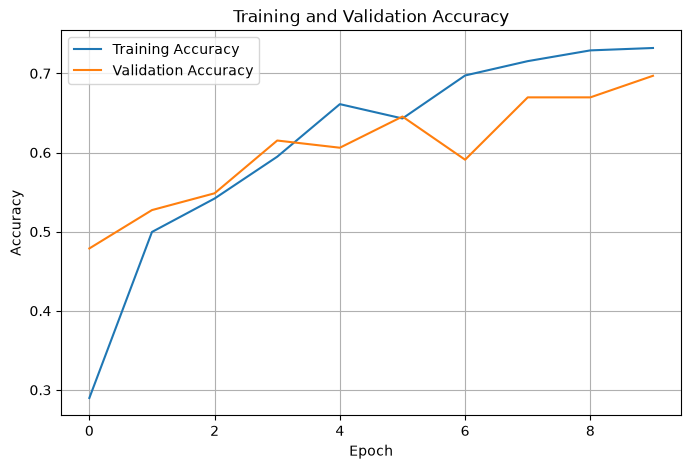

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title(
    'Training and Validation Accuracy'
)

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend()

plt.grid()

plt.show()

In [21]:
loss, accuracy = model.evaluate(
    validation_generator
)

print("Validation Loss:", loss)

print(
    "Validation Accuracy: {:.2f}%".format(
        accuracy * 100
    )
)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.6818 - loss: 0.8325
Validation Loss: 0.8324730396270752
Validation Accuracy: 68.18%


In [22]:
validation_generator.reset()

print("✅ Validation generator reset!")

✅ Validation generator reset!


In [23]:
predictions = model.predict(
    validation_generator
)

y_pred = np.argmax(
    predictions,
    axis=1
)

y_true = validation_generator.classes

print("Predictions generated successfully!")

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step
Predictions generated successfully!


In [24]:
print("Classification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

Classification Report:

                          precision    recall  f1-score   support

      fresh_peaches_done       0.84      0.82      0.83        50
 fresh_pomegranates_done       0.72      0.82      0.77        62
 fresh_strawberries_done       0.88      0.70      0.78        50
     rotten_peaches_done       0.62      0.71      0.66        68
rotten_pomegranates_done       0.59      0.54      0.56        50
rotten_strawberries_done       0.57      0.54      0.56        50

                accuracy                           0.69       330
               macro avg       0.70      0.69      0.69       330
            weighted avg       0.70      0.69      0.69       330



In [25]:
cm = confusion_matrix(
    y_true,
    y_pred
)

print("Confusion Matrix:\n")

print(cm)

Confusion Matrix:

[[41  3  0  5  1  0]
 [ 1 51  1  7  0  2]
 [ 0  3 35  1  0 11]
 [ 5  2  0 48  9  4]
 [ 2  5  1 12 27  3]
 [ 0  7  3  4  9 27]]


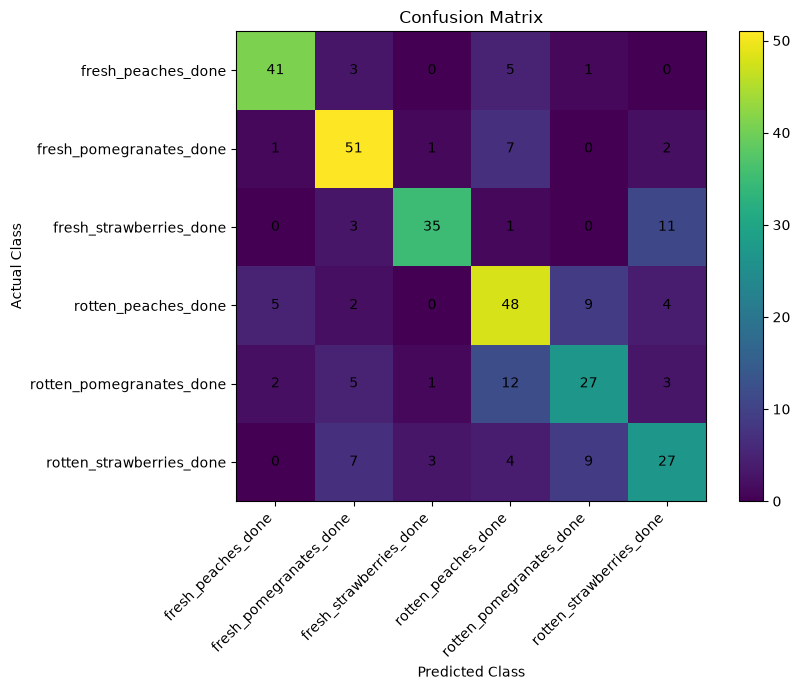

In [26]:
plt.figure(figsize=(9, 7))

plt.imshow(cm)

plt.title(
    'Confusion Matrix'
)

plt.xlabel(
    'Predicted Class'
)

plt.ylabel(
    'Actual Class'
)

plt.xticks(
    np.arange(len(class_names)),
    class_names,
    rotation=45,
    ha='right'
)

plt.yticks(
    np.arange(len(class_names)),
    class_names
)

for i in range(len(class_names)):
    
    for j in range(len(class_names)):
        
        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center'
        )

plt.colorbar()

plt.tight_layout()

plt.show()

In [27]:
cm_accuracy = np.trace(cm) / np.sum(cm)

print(
    "Confusion Matrix Accuracy: {:.2f}%".format(
        cm_accuracy * 100
    )
)

Confusion Matrix Accuracy: 69.39%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


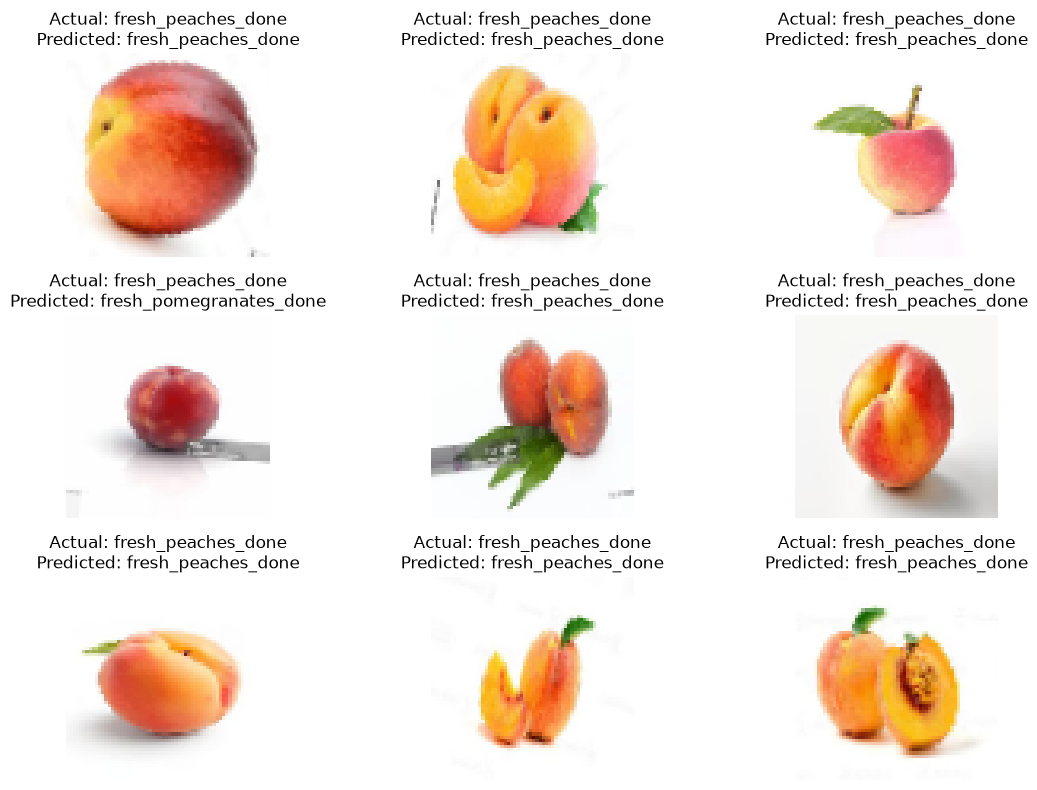

In [28]:
validation_generator.reset()

sample_images, sample_labels = next(
    validation_generator
)

sample_predictions = model.predict(
    sample_images
)

sample_pred_classes = np.argmax(
    sample_predictions,
    axis=1
)

plt.figure(figsize=(12, 8))

for i in range(9):
    
    plt.subplot(3, 3, i + 1)
    
    plt.imshow(sample_images[i])
    
    actual_class = class_names[
        np.argmax(sample_labels[i])
    ]
    
    predicted_class = class_names[
        sample_pred_classes[i]
    ]
    
    plt.title(
        f"Actual: {actual_class}\n"
        f"Predicted: {predicted_class}"
    )
    
    plt.axis('off')

plt.tight_layout()

plt.show()

In [29]:
print("=" * 50)
print("FINAL CNN MODEL RESULT")
print("=" * 50)

print("Dataset:", "Fruits Dataset for Classification")

print("Number of Classes:", len(class_names))

print("Classes:")

for name in class_names:
    print("-", name)

print(
    "\nValidation Accuracy: {:.2f}%".format(
        accuracy * 100
    )
)

print("Validation Loss:", loss)

print("=" * 50)

FINAL CNN MODEL RESULT
Dataset: Fruits Dataset for Classification
Number of Classes: 6
Classes:
- fresh_peaches_done
- fresh_pomegranates_done
- fresh_strawberries_done
- rotten_peaches_done
- rotten_pomegranates_done
- rotten_strawberries_done

Validation Accuracy: 68.18%
Validation Loss: 0.8324730396270752
